In [1]:
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

In [2]:
# calculate hashes needed in "trimming" step
def calc_hashes(k, b):
    Htrim = (2/k+2)
    red_edgs = (1-np.exp(-1))
    Hwalk = 41*(1/k*red_edgs+1)+1/k*red_edgs+1/k
    Hstep = 42 + (1/k**2)
    A = 1-(1-b/k)**42
    return (b*(Htrim+Hwalk)+Hstep)/A

def calc_memory_min(k, N):
    return 1/k * (1-(1/np.exp(1))) * (2 * np.log2(k) + 10.58) + (43*np.log2(N)/k**2)

def calc_memory_bloom(k, N):
    return 1/k * (1-(1/np.exp(1))) * (2.44 * np.log2(k) + 14.54) + (43*np.log2(N)/k**2)

def calc_memory_cuckoo(k, N):
    return 1/k * (1-(1/np.exp(1))) * (2.05 * np.log2(k) + 14.18) + (43*np.log2(N)/k**2)

In [3]:
# generate data for each k-factor
kfact = [2**i for i in range(7,14)]
batches = range(1, 64)
df_tot = pd.DataFrame([(k, b, calc_hashes(k, b)) for k in kfact for b in batches], columns=['k-factor','batches','hashes'])
df_tot = df_tot.set_index(['k-factor', 'batches'])
# get minimum values
df_min = df_tot.loc[df_tot.groupby('k-factor').hashes.idxmin()].reset_index()
df_tot

hashes
k-factor batches             
128      1         303.686294
         2         265.478442
         3         272.233755
         4         291.844132
         5         317.761275
...                       ...
8192     59       9850.613933
         60       9871.497936
         61       9892.494592
         62       9913.600224
         63       9934.811390

[441 rows x 1 columns]

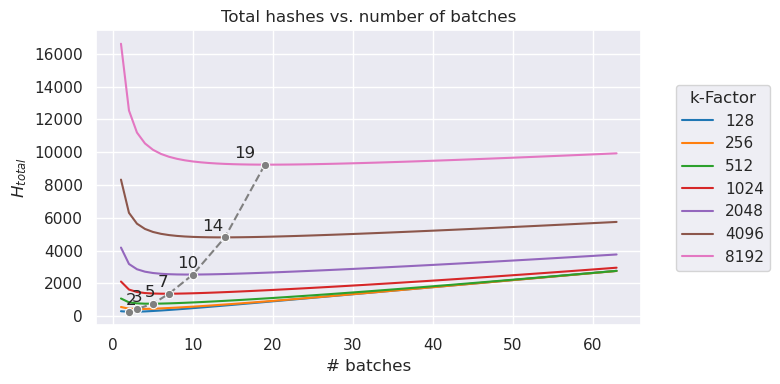

In [4]:
# plot graph
sns.set_theme()
plt.figure(figsize=(8, 4))
ax = sns.lineplot(x = 'batches', y = 'hashes', hue = 'k-factor', data = df_tot, palette="tab10")
ax = sns.lineplot(x = 'batches', y = 'hashes', data = df_min, linestyle='--', marker='o', color='grey')
ax.set(xlabel="# batches", ylabel='$H_{total}$', title = "Total hashes vs. number of batches")
ax.legend(title='k-Factor', loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=1)
for x, y in zip(df_min['batches'], df_min['hashes']):
    ax.text(x*(0.80), y+400, "%.0f" % x)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("hashes2batches.png")

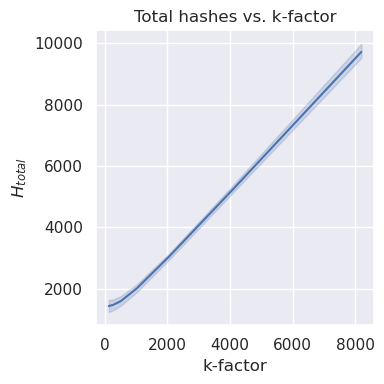

In [5]:
# plot graph
sns.set_theme()
plt.figure(figsize=(4, 4))
ax = sns.lineplot(x = 'k-factor', y = 'hashes', data = df_tot)
ax.set(xlabel="k-factor", ylabel='$H_{total}$', title = "Total hashes vs. k-factor")
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("hashes2kfact.png")

In [6]:
stats.linregress(x = df_tot.reset_index()["k-factor"], y = df_tot.reset_index()["hashes"])

LinregressResult(slope=np.float64(1.0406825009540195), intercept=np.float64(1087.2297304288554), rvalue=np.float64(0.9716998920990585), pvalue=np.float64(3.00548515441738e-277), stderr=np.float64(0.012074475909979917), intercept_stderr=np.float64(43.16833788403762))

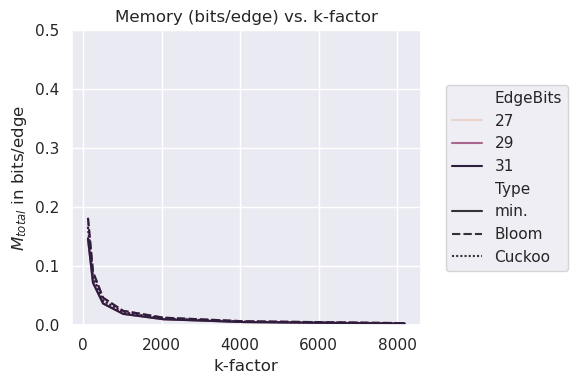

In [7]:
# calculate data
EdgeBits = [27, 29, 31]
s = []
for n in EdgeBits:
    for k in kfact:
        s.append({'EdgeBits': n, 'kFact': k, 'Type' : 'min.', 'bits' : calc_memory_min(k, n**2)})
        s.append({'EdgeBits': n, 'kFact': k, 'Type' : 'Bloom', 'bits' : calc_memory_bloom(k, n**2)})
        s.append({'EdgeBits': n, 'kFact': k, 'Type' : 'Cuckoo', 'bits' : calc_memory_cuckoo(k, n**2)})
mem_data = pd.DataFrame(s)

# plot graph
sns.set_theme()
plt.figure(figsize=(6, 4))
ax = sns.lineplot(x = 'kFact', y = 'bits', hue = 'EdgeBits', style = 'Type', data = mem_data)
ax.set(xlabel="k-factor", ylabel='$M_{total}$ in bits/edge', title = "Memory (bits/edge) vs. k-factor")
ax.set(ylim=(0, 0.5))
ax.legend(title='', loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=1)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("bits2kfact.png")

In [8]:
# calculate data
N = [27, 29, 31]
s = []
for k in kfact:
    # find optimal batching
    b_opt = np.argmin([calc_hashes(k, b) for b in range(1,128)])
    # calculate hashes
    hash_opt = calc_hashes(k, b_opt)
    for n in N:
        mem_min = calc_memory_min(k, n)
        mem_bloom = calc_memory_bloom(k, n)
        mem_cuckoo = calc_memory_cuckoo(k, n)
        T_min = (mem_min * hash_opt) / 56.6
        T_bloom = (mem_bloom * hash_opt) / 56.6
        T_cuckoo = (mem_cuckoo * hash_opt) / 56.6
        s.append({'EdgeBits': n, 'kFact': k, 'Type' : 'min.', 'T' : T_min, 'mem_k': 1/mem_min })
        s.append({'EdgeBits': n, 'kFact': k, 'Type' : 'Bloom', 'T' : T_bloom, 'mem_k': 1/mem_bloom })
        s.append({'EdgeBits': n, 'kFact': k, 'Type' : 'Cuckoo', 'T' : T_cuckoo, 'mem_k': 1/mem_cuckoo})
t_data = pd.DataFrame(s)
t_data

,EdgeBits,kFact,Type,T,mem_k
0,27,128,min.,0.718256,7.470148
1,27,128,Bloom,0.904796,5.930045
2,27,128,Cuckoo,0.822920,6.520052
3,29,128,min.,0.719708,7.455080
4,29,128,Bloom,0.906248,5.920545
...,...,...,...,...,...
58,29,8192,Bloom,0.583714,279.901902
59,29,8192,Cuckoo,0.515257,317.089440
60,31,8192,min.,0.461687,353.881763
61,31,8192,Bloom,0.583724,279.897072


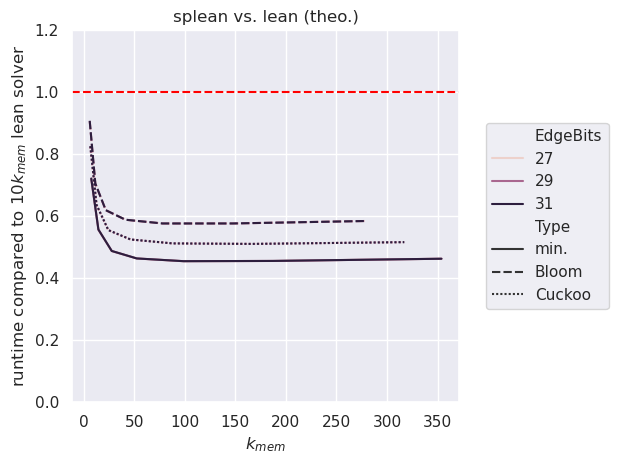

In [10]:
# plot graph
ax = sns.lineplot(x = 'mem_k', y = 'T', hue = 'EdgeBits', style = 'Type', data = t_data)
ax.set(xlabel="$k_{mem}$", ylabel='runtime compared to $10k_{mem}$ lean solver', title = "splean vs. lean (theo.)")
ax.set(ylim=(0, 1.2))
#ax.set(xlim=(0, 20))
ax.legend(title='', loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=1)
ax.axhline(1.0, ls='--', color="red")
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("splean2lean_theo.png")